(2000, 4)



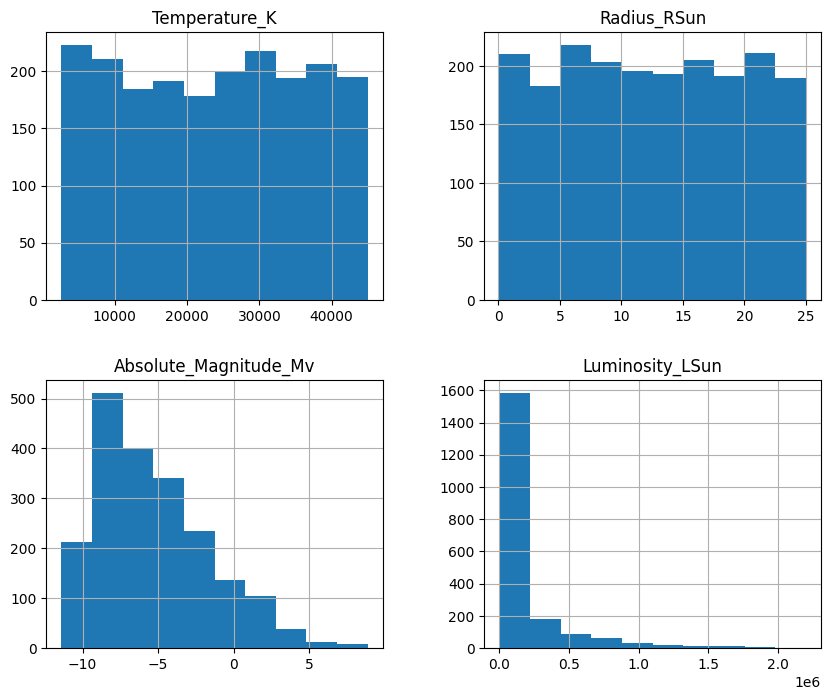


   Temperature_K  Radius_RSun  Absolute_Magnitude_Mv
0        18418.0       6.6017                -4.5221
1        42905.4       6.2347                -8.1748
2        33609.7      22.6639                -9.4463
3        27943.0       6.2987                -6.5893
4         9130.8       6.8570                -1.3012
0      5277.282731
1    122712.960567
2    546777.178330
3     22921.409793
4       277.501106
Name: Luminosity_LSun, dtype: float64

X_train: (1600, 3)
X_test: (400, 3)
y_train: (1600,)
y_test: (400,)

Coefficients:
[2.57106396e+01 3.16883803e+04 5.08804293e+04]
Intercept:
-574442.856982545


MAE: 159677.6577150795
MSE: 56238694270.96181
R2 Score: 0.5667934553059912
R² Score best explains model performance because it shows how much of the variation in stellar luminosity is explained by the model



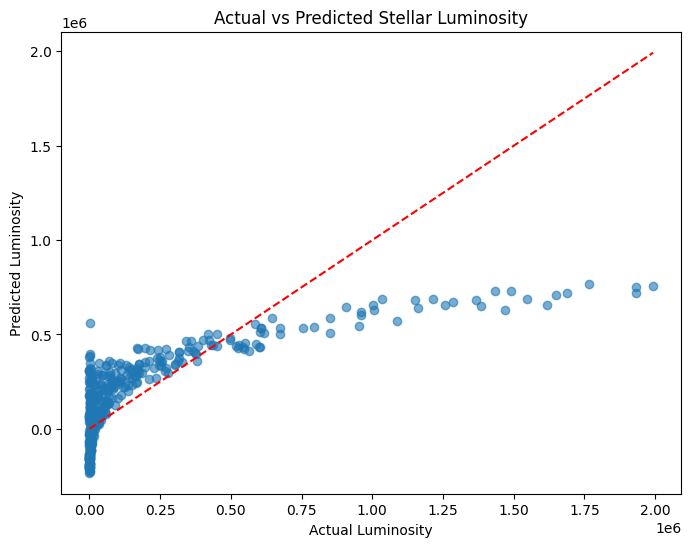

The predictions are moderately accurate, as the model captures the general trend but still has noticeable prediction errors


In [ ]:
#TASK 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df=pd.read_csv("https://raw.githubusercontent.com/shanks-pony-3140/equinox101/main/week2/stellar_data.csv")
df.head()
print(df.shape)
print()

#---------------------------------#
#TASK 2

df.isnull().sum()
df.describe()

df.hist(figsize=(10,8))
plt.show()
print()

#--------------------------------#
#TASK 3

X=df[['Temperature_K','Radius_RSun','Absolute_Magnitude_Mv']]
y=df['Luminosity_LSun']
print(X.head())
print(y.head())
print()

#---------------------------------#
#TASK 4

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)
print()

#---------------------------------#
#TASK 5

model=LinearRegression()
model.fit(X_train,y_train)
print("Coefficients:")
print(model.coef_)
print("Intercept:")
print(model.intercept_)
print()

#---------------------------------#
#TASK 6

y_pred=model.predict(X_test)
comparison=pd.DataFrame({'Actual':y_test.values,'Predicted':y_pred})
comparison.head(10)
print()

#--------------------------------#
#TASK 7

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)

r2=r2_score(y_test,y_pred)
print("R2 Score:",r2)
print("R² Score best explains model performance because it shows how much of the variation in stellar luminosity is explained by the model")
print()

#--------------------------------#
#TASK 8

plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,alpha=0.6)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel("Actual Luminosity")
plt.ylabel("Predicted Luminosity")
plt.title("Actual vs Predicted Stellar Luminosity")
plt.show()
print("The predictions are moderately accurate, as the model captures the general trend but still has noticeable prediction errors")
